## Import Libraries

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

In [92]:
iris = load_iris()
X = iris.data[:, :2] ##using only 2 features
y = (iris.target == 2).astype(int) ## using only 1 class 


In [75]:
pd.Series(y).value_counts()

,count
0,100
1,50


In [93]:
## split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.3)

In [98]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [99]:
## Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("confusion matrix:", confusion_matrix(y_test, y_pred))
print("Classification report:", classification_report(y_test, y_pred))

Accuracy: 0.8444444444444444
confusion matrix: [[27  5]
 [ 2 11]]
Classification report:               precision    recall  f1-score   support

           0       0.93      0.84      0.89        32
           1       0.69      0.85      0.76        13

    accuracy                           0.84        45
   macro avg       0.81      0.84      0.82        45
weighted avg       0.86      0.84      0.85        45



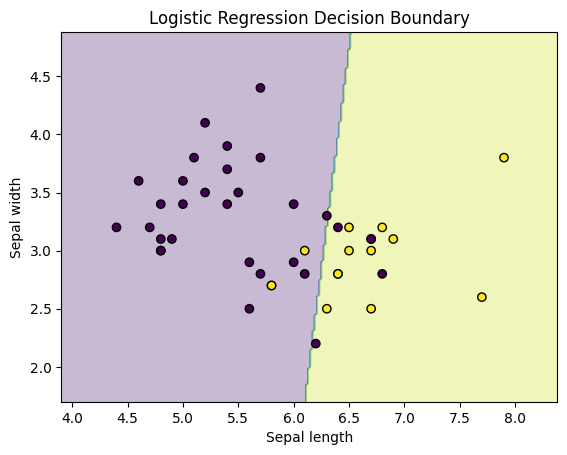

In [100]:
## decision boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('Logistic Regression Decision Boundary')
    plt.show()

plot_decision_boundary(X_test, y_test, model)

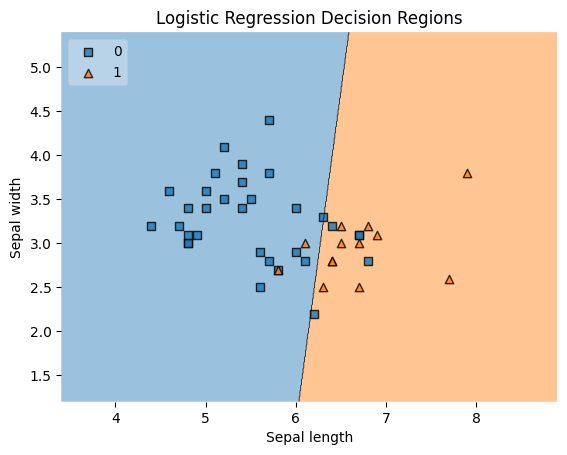

In [101]:
from mlxtend.plotting import plot_decision_regions
def plot_decision_boundary_mlxtend(X, y, model):
    plot_decision_regions(X=X, y=y.astype(int), clf=model, legend=2)

    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('Logistic Regression Decision Regions')
    plt.show()

plot_decision_boundary_mlxtend(X_test, y_test, model)

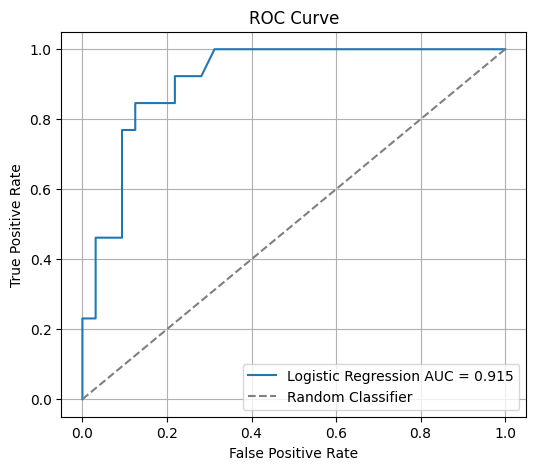

In [104]:
## ROC Curve
# Get probability scores for positive class
y_proba = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# AUC score
auc_score = roc_auc_score(y_test, y_proba)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## From scratch

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

class Logistic:
    def __init__(self, learning_rate = 0.01, epochs = 1000, threshold = 0.5):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.threshold = threshold
        self.weights = None
        self.bias = None
    def sigmoid(self, z):
        return 1 / (1  + np.exp(-z))
    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        for _ in range(self.epochs):
            linear_model = X @ self.weights + self.bias
            y_pred = self.sigmoid(linear_model)
            
            dw = (1/ m) * (X.T @ (y_pred - y))
            db = (1 /m) * np.sum(y_pred - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
    
    def predict_prob(self, X):
        linear_model = X @ self.weights + self.bias
        return self.sigmoid(linear_model)
    def predict(self, X):
        probabilities = self.predict_prob(X)
        return (probabilities >= self.threshold).astype(int)
    def evaluate(self, X, y):
        y_pred = self.predict(X)
        
        print("Accuracy:", accuracy_score(y, y_pred))
        print("Confusion Matrix:")
        print(confusion_matrix(y, y_pred))
        print("Classification Report:")
        print(classification_report(y, y_pred))

In [6]:
data = load_breast_cancer()
X = data.data
y = data.target
# Logistic = Logistic()
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size= 0.3,random_state= 42)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = Logistic(
    learning_rate=0.01,
    epochs=5000,
    threshold=0.5
)

model.fit(X_train, y_train)

# Evaluate
model.evaluate(X_test, y_test)

Accuracy: 0.9883040935672515
Confusion Matrix:
[[ 62   1]
 [  1 107]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        63
           1       0.99      0.99      0.99       108

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



## Logistic CV

In [105]:
from sklearn.linear_model import LogisticRegressionCV

In [113]:
model_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(cv= 5, max_iter=100, Cs= 10, scoring= "roc_auc"))
])
model_cv.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [115]:
accuracy = accuracy_score(y_pred, y_test)
y_prob_cv = model_cv.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy)

Accuracy: 0.8222222222222222


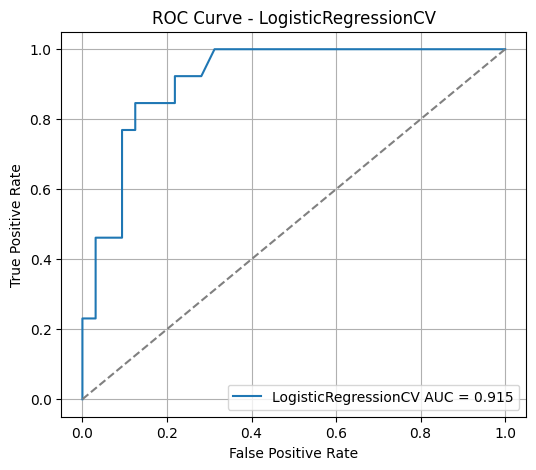

In [116]:
### ROC curve

fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_test, y_prob_cv)
auc_cv = roc_auc_score(y_test, y_prob_cv)

plt.figure(figsize=(6, 5))
plt.plot(fpr_cv, tpr_cv, label=f"LogisticRegressionCV AUC = {auc_cv:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LogisticRegressionCV")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ROC/AUC asks: “Are positives ranked above negatives?”

# Accuracy asks: “Did the final class label match?”

# Log loss asks: “How confident was the model, and was that confidence correct?”b

In [ ]:
from sklearn.metrics import log_loss  ## LOWER == better

# Logistic Regression
y_proba_lr = model.predict_proba(X_test)

# LogisticRegressionCV
y_proba_cv = model_cv.predict_proba(X_test)

print("Logistic Regression Log Loss:", log_loss(y_test, y_proba_lr))
print("LogisticRegressionCV Log Loss:", log_loss(y_test, y_proba_cv))


Logistic Regression Log Loss: 0.35417847491667104
LogisticRegressionCV Log Loss: 0.6093096605150566


## Multi-Class

In [ ]:
## Let's try on multi class
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, label_binarize 
## Label binarize: It is mostly used when you have multi-class classification and you want to convert your labels into a one-hot encoded format.
from sklearn.metrics import roc_auc_score, roc_curve


In [ ]:
# Given 13 chemical properties of a wine, predict which of the 3 wine classes it belongs to

In [134]:
wine = load_wine()
X,y = wine.data, wine.target
## split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3,random_state= 42)


In [130]:
from sklearn.pipeline import Pipeline
Pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(multi_class= 'multinomial', solver='lbfgs', max_iter=1000,random_state= 42))
])
Pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    random_state=42))])

In [140]:
y_pred = Pipe.predict(X_test)
y_proba = Pipe.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_proba))
print("ROC AUC OVR:", roc_auc_score(y_test, y_proba, multi_class="ovr"))
print("ROC AUC OVO:", roc_auc_score(y_test, y_proba, multi_class="ovo"))

print(classification_report(y_test, y_pred, target_names=wine.target_names))


Accuracy: 0.9814814814814815
Log Loss: 0.060237189795122985
ROC AUC OVR: 0.9995189995189996
ROC AUC OVO: 0.9995822890559732
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      0.95      0.98        21
     class_2       0.93      1.00      0.97        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



## Mutliclass Logistic CV

In [142]:
wine_model_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegressionCV(
        Cs = 10,
        cv= 5,
        max_iter= 1000,
        multi_class= 'multinomial',
        scoring= 'accuracy',
        random_state= 42
    ))
])
wine_model_cv.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1908: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegressionCV(cv=5, max_iter=1000,
                                      multi_class='multinomial',
                                      random_state=42, scoring='accuracy'))])

In [143]:
y_pred_cv = wine_model_cv.predict(X_test)
y_proba_cv = wine_model_cv.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_cv))
print("Log Loss:", log_loss(y_test, y_proba_cv))

print(classification_report(
    y_test,
    y_pred_cv,
    target_names=wine.target_names
))


Accuracy: 0.9814814814814815
Log Loss: 0.06886555020982477
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      0.95      0.98        21
     class_2       0.93      1.00      0.97        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



## LR to PCA


To visualize decision boundaries, you need 2D input. But load_wine has 13 features, so you have two good options:

Use only 2 real features
Reduce 13 features to 2D using PCA

In [146]:
model_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('model', LogisticRegressionCV(
        Cs = 10,
        cv= 5,
        max_iter= 1000,
        scoring= "accuracy"
    ))
])
model_pca.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('model',
                 LogisticRegressionCV(cv=5, max_iter=1000,
                                      scoring='accuracy'))])

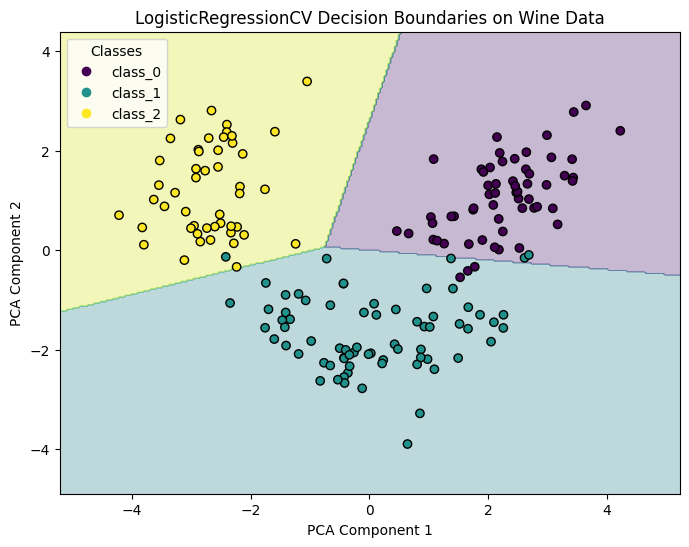

In [147]:
# Convert full X into 2D PCA space for plotting points
X_2d = model_pca.named_steps["pca"].transform(
    model_pca.named_steps["scaler"].transform(X)
)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predict directly using PCA-space classifier step
Z = model_pca.named_steps["model"].predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("LogisticRegressionCV Decision Boundaries on Wine Data")
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=list(wine.target_names),
    title="Classes"
)
plt.show()
